# Task 0 — Data Exploratory Analysis (EDA) sul Dataset QEvasion

Questo notebook analizza il dataset utilizzato per il fine-tuning di Llama 3.1.
L'obiettivo è estrarre statistiche utili sulle distribuzioni delle etichette (Clarity ed Evasion), calcolare la lunghezza media dei testi e visualizzare la correlazione tra le tecniche di evasione e le macro-categorie di chiarezza.

In [34]:
# ============================================================
# CELLA 1 — Setup e Importazione Librerie
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
import sys
from pathlib import Path

# Stile dei grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Configurazione dei percorsi e rilevamento ambiente (Colab / Locale)
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("Ambiente Google Colab rilevato. Google Drive montato con successo.")

    # Percorso base su Google Drive
    BASE_DIR = "/content/drive/MyDrive/progettoLLM"

except ImportError:
    print("Ambiente locale rilevato.")

    # Percorso base locale (impostato alla root del progetto corrente)
    BASE_DIR = "."

REPO_DIR = os.path.join(BASE_DIR, "CLARITY")

# Percorso per il salvataggio dei grafici e dei risultati dell'analisi
ANALYSIS_DIR = os.path.join(REPO_DIR, "analisi_dataset")
os.makedirs(ANALYSIS_DIR, exist_ok=True)
print(f"Directory di output impostata su: {ANALYSIS_DIR}")


PROJECT_ROOT = Path(REPO_DIR).resolve()   # notebooks/ is one level below root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
Ambiente Google Colab rilevato. Google Drive montato con successo.
Directory di output impostata su: /content/drive/MyDrive/progettoLLM/CLARITY/analisi_dataset


In [35]:
# ============================================================
# CELLA 2 — Caricamento Dataset e Conversione in Pandas
# ============================================================
from src.data.dataset_loader import load_and_split_dataset

raw_ds = load_and_split_dataset(seed=42, verbose=True)

dataset_train = raw_ds['train']
dataset_test  = raw_ds['test']

# Conversione in DataFrame Pandas per l'analisi statistica
df_train = dataset_train.to_pandas()
df_test  = dataset_test.to_pandas()

# Aggiunta colonna per l'identificazione dello split
df_train['split'] = 'Train'
df_test['split'] = 'Test'

# Unione in un singolo DataFrame
df_all = pd.concat([df_train, df_test], ignore_index=True)

print("Dataset caricato con successo.")
print(f" - Esempi in Train: {len(df_train)}")
print(f" - Esempi in Test:  {len(df_test)}")
print(f" - Totale Esempi:   {len(df_all)}\n")

display(df_all.head(3))

  train       :  2758 samples
  validation  :   690 samples
  test        :   308 samples
Dataset caricato con successo.
 - Esempi in Train: 2758
 - Esempi in Test:  308
 - Totale Esempi:   3066



,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label,split
0,The President's News Conference With Prime Min...,"May 16, 2013",Barack Obama,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Thank you, Mr. President. I'd like to ask y...","Well, I'll let you guys engage in those compar...",The question consists of 4 parts:\n\n1. Do you...,Question part: 1. Do you believe that the seiz...,How do you feel about comparisons by some of y...,...,None,None,None,False,False,False,2198,Clear Non-Reply,Declining to answer,Train
1,The President's News Conference,"December 22, 2010",Barack Obama,https://www.presidency.ucsb.edu/documents/the-...,4,"Q. Yes, sir. Mr. President, can you explain th...","Look, the frustration that people felt about t...",The question consists of 2 parts:\n\n1. Anger ...,Question part: 1. Anger and outrage of Democra...,Is that a divide that you may be contributing ...,...,None,None,None,False,False,False,2505,Ambivalent,Implicit,Train
2,The President's News Conference With President...,"August 06, 2008",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,2,"Q. Thank you, both. To President Bush, China's...",I've been meeting with Chinese leaders now for...,The question consists of 2 parts:\n\n1. To Pre...,"Question part: 1. To President Bush - ""What do...",For people who think that this is just another...,...,None,None,None,False,False,False,2774,Ambivalent,General,Train


--- Distribuzione Etichette di Chiarezza (Task 1) ---
clarity_label
Ambivalent         1817
Clear Reply         938
Clear Non-Reply     311
Name: count, dtype: int64

Percentuali:
clarity_label
Ambivalent         59.262883
Clear Reply        30.593607
Clear Non-Reply    10.143509
Name: proportion, dtype: float64


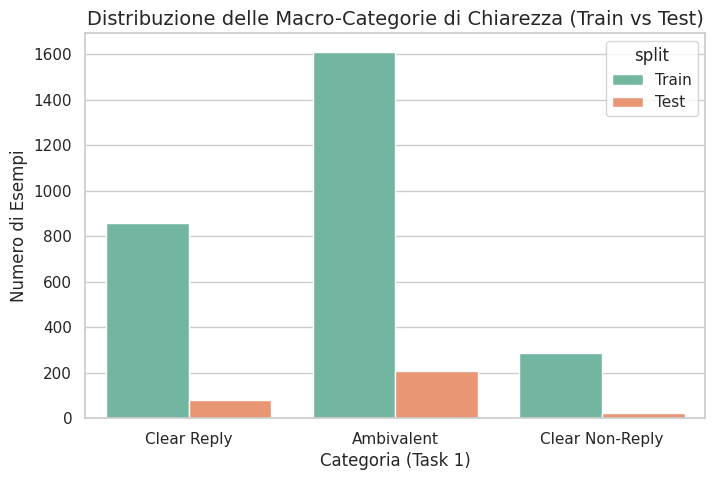

In [36]:
# ============================================================
# CELLA 3 — Distribuzione Macro-Categorie (Task 1: Clarity)
# ============================================================

print("--- Distribuzione Etichette di Chiarezza (Task 1) ---")
clarity_counts = df_all['clarity_label'].value_counts()
print(clarity_counts)
print(f"\nPercentuali:\n{df_all['clarity_label'].value_counts(normalize=True) * 100}")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_all, x='clarity_label', hue='split', palette='Set2',
                   order=["Clear Reply", "Ambivalent", "Clear Non-Reply"])

plt.title('Distribuzione delle Macro-Categorie di Chiarezza (Train vs Test)', fontsize=14)
plt.xlabel('Categoria (Task 1)', fontsize=12)
plt.ylabel('Numero di Esempi', fontsize=12)

# Salva il grafico
plt.savefig(f"{ANALYSIS_DIR}/distribuzione_clarity.png", bbox_inches='tight', dpi=300)
plt.show()

--- Distribuzione Tecniche di Evasione (Task 2) ---
evasion_label
Explicit               938
Dodging                607
Implicit               438
General                375
Deflection             327
Declining to answer    129
Claims ignorance       106
Clarification           76
Partial/half-answer     70
Name: count, dtype: int64


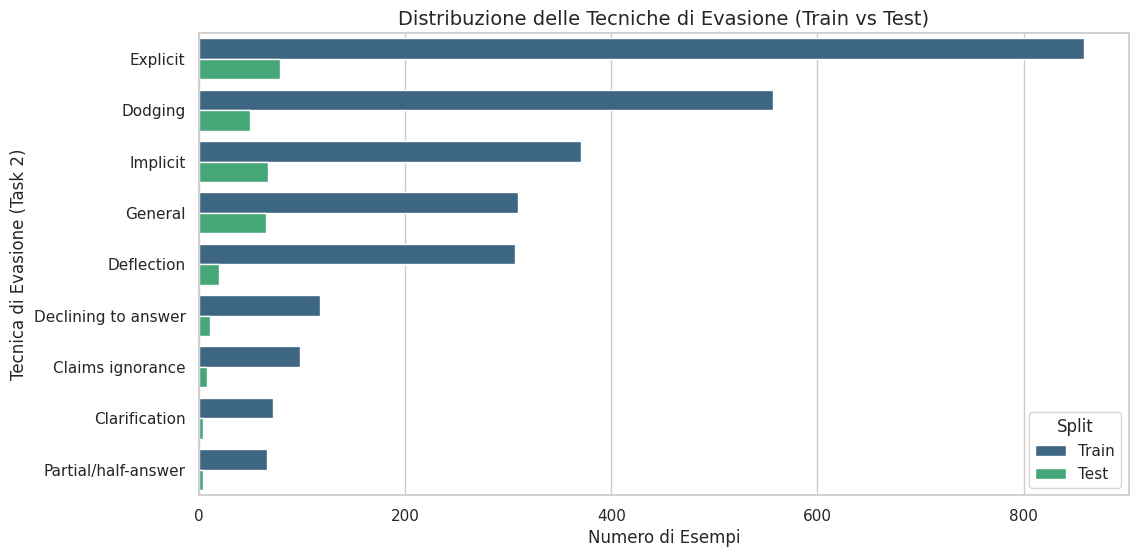

In [37]:
# ============================================================
# CELLA 4 — Distribuzione Tecniche di Evasione (Task 2)
# ============================================================

print("--- Distribuzione Tecniche di Evasione (Task 2) ---")
evasion_counts = df_all['evasion_label'].value_counts()
print(evasion_counts)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_all, y='evasion_label', hue='split', palette='viridis',
                   order=evasion_counts.index)

plt.title('Distribuzione delle Tecniche di Evasione (Train vs Test)', fontsize=14)
plt.xlabel('Numero di Esempi', fontsize=12)
plt.ylabel('Tecnica di Evasione (Task 2)', fontsize=12)
plt.legend(title='Split', loc='lower right')

plt.savefig(f"{ANALYSIS_DIR}/distribuzione_evasion.png", bbox_inches='tight', dpi=300)
plt.show()

--- Statistiche Lunghezza Testi (Numero di Parole) ---


,word_count_question,word_count_answer
count,3066.000000,3066.000000
mean,61.139596,293.088715
std,59.797315,297.040009
min,3.000000,1.000000
25%,23.000000,61.000000
50%,51.000000,209.500000
75%,81.000000,436.000000
max,780.000000,2117.000000


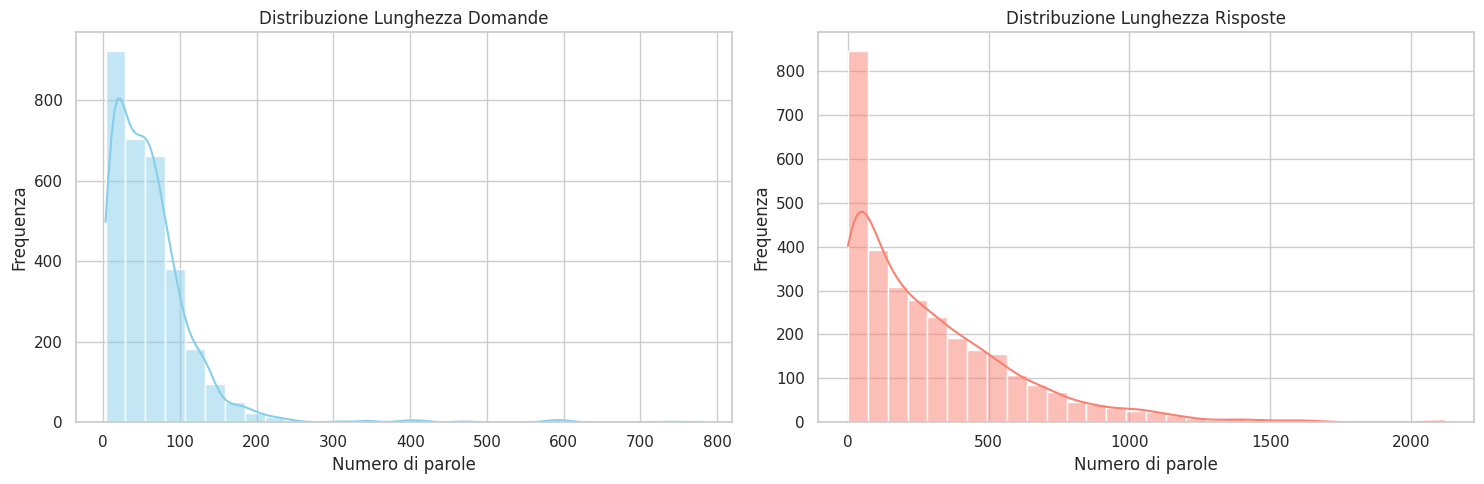

In [38]:
# ============================================================
# CELLA 5 — Analisi della Lunghezza dei Testi (Word Count)
# ============================================================

# Calcoliamo il numero di parole per domanda e risposta
df_all['word_count_question'] = df_all['interview_question'].apply(lambda x: len(str(x).split()))
df_all['word_count_answer']   = df_all['interview_answer'].apply(lambda x: len(str(x).split()))

print("--- Statistiche Lunghezza Testi (Numero di Parole) ---")
display(df_all[['word_count_question', 'word_count_answer']].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma Domande
sns.histplot(df_all['word_count_question'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribuzione Lunghezza Domande')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')

# Istogramma Risposte
sns.histplot(df_all['word_count_answer'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribuzione Lunghezza Risposte')
axes[1].set_xlabel('Numero di parole')
axes[1].set_ylabel('Frequenza')

plt.tight_layout()
plt.savefig(f"{ANALYSIS_DIR}/lunghezza_testi.png", bbox_inches='tight', dpi=300)
plt.show()

--- Crosstab: Evasion Label vs Clarity Label ---


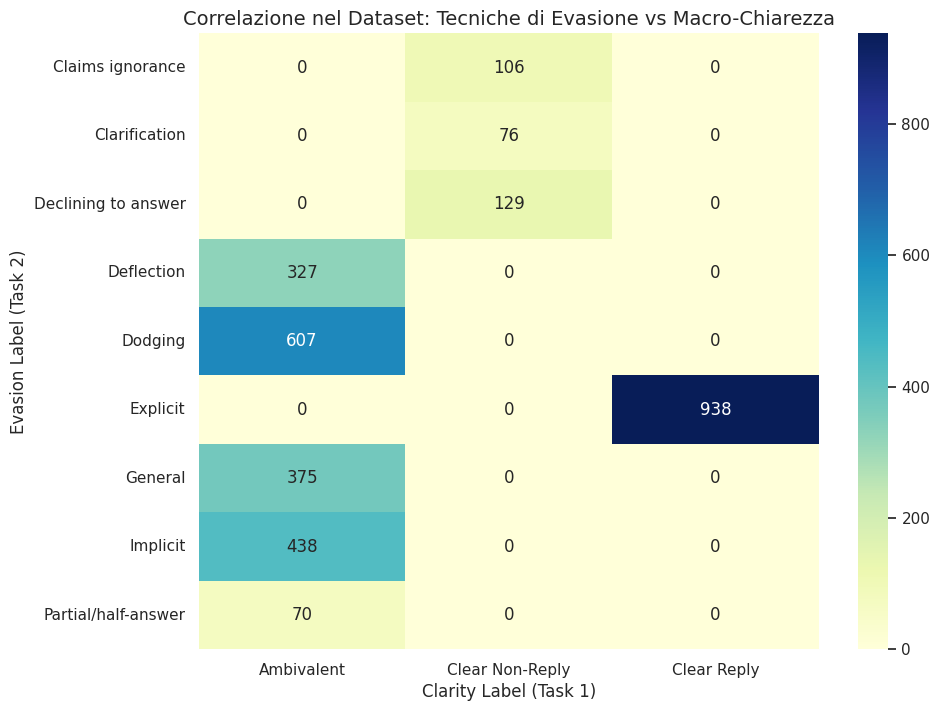

Analisi completata! Grafici e dati salvati in: /content/drive/MyDrive/progettoLLM/CLARITY/analisi_dataset


In [39]:
# ============================================================
# CELLA 6 — Matrice di Correlazione (Task 2 -> Task 1)
# ============================================================
# Vogliamo vedere esattamente come le etichette di Evasione si
# traducono in etichette di Chiarezza nel Dataset Reale (Ground Truth).

print("--- Crosstab: Evasion Label vs Clarity Label ---")
crosstab_df = pd.crosstab(df_all['evasion_label'], df_all['clarity_label'])

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Correlazione nel Dataset: Tecniche di Evasione vs Macro-Chiarezza', fontsize=14)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Evasion Label (Task 2)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/heatmap_correlazione_t1_t2.png", bbox_inches='tight', dpi=300)
plt.show()

# Salvataggio del dataset con le statistiche calcolate
df_all.to_csv(f"{ANALYSIS_DIR}/dataset_statistiche_complete.csv", index=False)
print(f"Analisi completata! Grafici e dati salvati in: {ANALYSIS_DIR}")

In [40]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Inizializzazione modello con FP16 (obbligatorio per velocità su T4)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0,
                      torch_dtype=torch.float16)

candidate_labels = ["Assertive", "Guarded", "Dismissive"]

# 2. Trasformiamo la colonna in un oggetto Dataset di Hugging Face
# Tagliamo a 200 parole per assicurarci che la GPU non si "incanti"
print("Preparazione dati...")
temp_df = pd.DataFrame({
    "text": df_all['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:200]))
})
dataset = Dataset.from_pandas(temp_df)

# 3. Esecuzione con la struttura Dataset + Pipeline + tqdm
results = []
batch_size = 16

print(f"Inizio analisi batch di {len(dataset)} righe...")

for out in tqdm(classifier(KeyDataset(dataset, "text"),
                           candidate_labels=candidate_labels,
                           batch_size=batch_size,
                           truncation=True),
                total=len(dataset)):
    results.append(out['labels'][0])

# 4. Assegnazione finale
df_all['tone'] = results
print("Analisi completata!")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Preparazione dati...
Inizio analisi batch di 3066 righe...


  0%|          | 0/3066 [00:00<?, ?it/s]

Analisi completata!


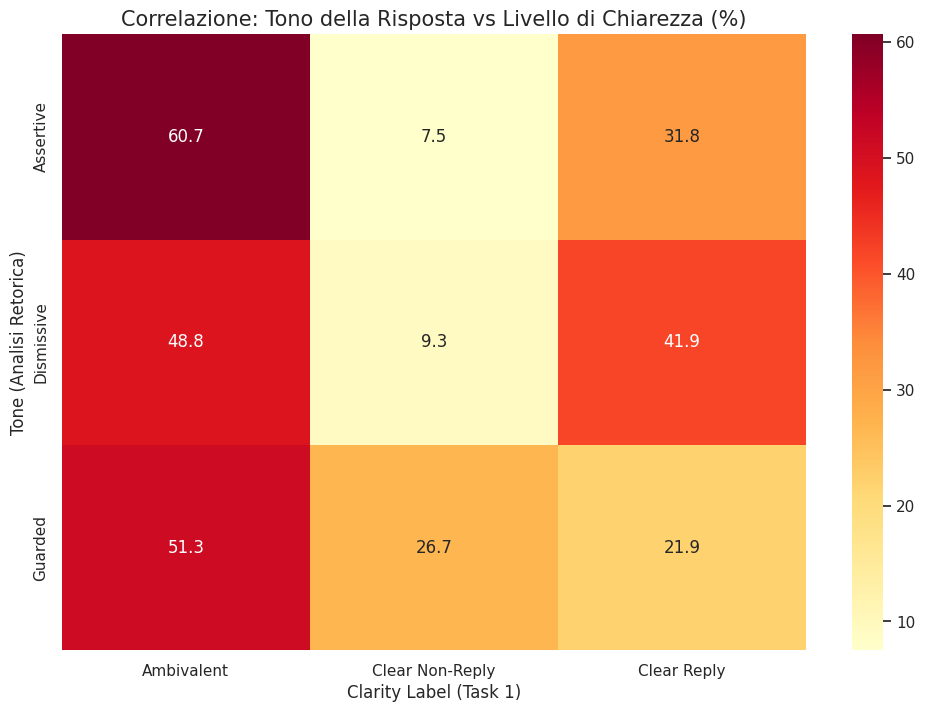

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo la tabella di contingenza (Crosstab)
tone_clarity_crosstab = pd.crosstab(df_all['tone'], df_all['clarity_label'], normalize='index') * 100

# Mostriamo la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tone_clarity_crosstab, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Correlazione: Tono della Risposta vs Livello di Chiarezza (%)', fontsize=15)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Tone (Analisi Retorica)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/heatmap_tone_clarity_4.png", bbox_inches='tight')
plt.show()

In [42]:
import pandas as pd
import numpy as np

# Usiamo pd.qcut per dividere in 3 gruppi con lo stesso numero di campioni (terzili)
# labels=["Short", "Medium", "Large"]
df_all['length_category'] = pd.qcut(df_all['word_count_answer'], 3, labels=["Short", "Medium", "Large"])

# Vediamo i range di parole per ogni categoria
bins = pd.qcut(df_all['word_count_answer'], 3, retbins=True)[1]
print(f"Range Short: {bins[0]:.0f} - {bins[1]:.0f} parole")
print(f"Range Medium: {bins[1]:.0f} - {bins[2]:.0f} parole")
print(f"Range Large: {bins[2]:.0f} - {bins[3]:.0f} parole")

Range Short: 1 - 102 parole
Range Medium: 102 - 344 parole
Range Large: 344 - 2117 parole


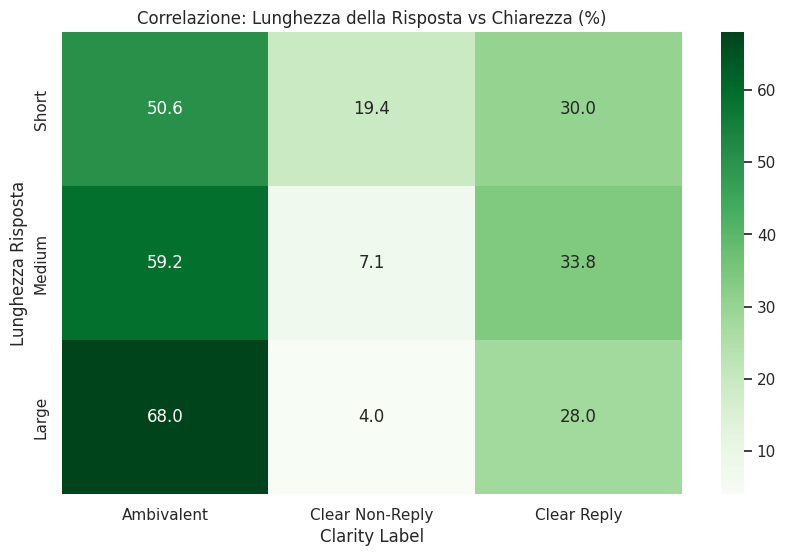

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Crosstab normalizzata per riga
length_clarity_ct = pd.crosstab(df_all['length_category'], df_all['clarity_label'], normalize='index') * 100

sns.heatmap(length_clarity_ct, annot=True, fmt='.1f', cmap='Greens')
plt.title('Correlazione: Lunghezza della Risposta vs Chiarezza (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Lunghezza Risposta')
plt.show()

In [44]:
# ============================================================
# Ribilanciamento Strategico del Dataset (Smart Resampling)
# ============================================================
import pandas as pd
from collections import Counter
from datasets import Dataset, DatasetDict

# Poiché le funzioni in resampling.py si aspettano un DatasetDict con almeno la chiave 'train',
# e tu hai df_all (che è un DataFrame Pandas), lo riconvertiamo temporaneamente.
# In questo caso, consideriamo tutto df_all come 'train' per il bilanciamento,
# o meglio, separiamo prima il vero Train dal Test (come hai fatto nella Cella 2).

print("Preparazione dei dati per il resampling...")

# Ristrutturiamo in DatasetDict usando la colonna 'split' creata in Cella 2
train_df = df_all[df_all['split'] == 'Train'].reset_index(drop=True)
test_df = df_all[df_all['split'] == 'Test'].reset_index(drop=True)

raw_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df),
    "validation": Dataset.from_pandas(test_df) # Mettiamo il test anche come validation se manca
})

# Importiamo la funzione di resampling intelligente dal tuo modulo
from src.data.resampling import smart_resampling

# Mappatura etichette fittizia (necessaria per la firma della funzione, ma gestita internamente dal tuo codice stringa)
dummy_label2id = {label: i for i, label in enumerate(train_df['clarity_label'].unique())}

# ESECUZIONE DELLA PIPELINE DI RESAMPLING SUL SET A 3 CLASSI ('clarity_label')
print("\\nAvvio Smart Resampling (Semantic Downsampling + Paraphrase Upsampling)...")
# Nota: Modifichiamo temporaneamente LABEL_COLUMN dentro il modulo se necessario,
# oppure passiamo 'clarity_label' se la tua funzione modificata lo accetta.
import src.data.resampling as res_module
res_module.LABEL_COLUMN = "clarity_label"

# Eseguiamo il bilanciamento "soft"
balanced_dict = smart_resampling(
    ds=raw_dict,
    label2id=dummy_label2id,
    strategy="soft",      # Usa la logica del tetto massimo (es. taglia il 40% della classe maggiore)
    down_ratio=0.60,      # Punta a portare la classe maggiore al 60% della sua grandezza originale
    embed_column="interview_answer",
    paraphrase_column="interview_answer",
    seed=42
)

# Estraiamo di nuovo i dati bilanciati in formato Pandas per le tue Heatmap successive
df_train_balanced = balanced_dict['train'].to_pandas()
df_train_balanced['split'] = 'Train'

# Uniamo di nuovo con il Test set intatto
df_final_balanced = pd.concat([df_train_balanced, test_df]).reset_index(drop=True)

print("\\n--- Distribuzione Classi sul Train Set Bilanciato ---")
print(df_final_balanced[df_final_balanced['split'] == 'Train']['clarity_label'].value_counts())


Preparazione dei dati per il resampling...
\nAvvio Smart Resampling (Semantic Downsampling + Paraphrase Upsampling)...

[smart_resampling] Target Distribution (Strategy: 'soft'):
  Clear Non-Reply: 288 → 576
  Ambivalent: 1611 → 966
  Clear Reply: 859 → 966

[semantic_downsampling] Initializing 'all-MiniLM-L6-v2'...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Filter:   0%|          | 0/2758 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2758 [00:00<?, ? examples/s]

...

  Paraphrasing 'Clear Non-Reply':   0%|          | 0/18 [00:00<?, ?it/s]

Flattening the indices:   0%|          | 0/859 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/966 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/288 [00:00<?, ? examples/s]

\n--- Distribuzione Classi sul Train Set Bilanciato ---
clarity_label
Ambivalent         966
Clear Reply        966
Clear Non-Reply    576
Name: count, dtype: int64


In [45]:
import pandas as pd
import numpy as np

# Usiamo pd.qcut per dividere in 3 gruppi con lo stesso numero di campioni (terzili)
# labels=["Short", "Medium", "Large"]
df_final_balanced['length_category'] = pd.qcut(df_final_balanced['word_count_answer'], 3, labels=["Short", "Medium", "Large"])

# Vediamo i range di parole per ogni categoria
bins = pd.qcut(df_final_balanced['word_count_answer'], 3, retbins=True)[1]
print(f"Range Short: {bins[0]:.0f} - {bins[1]:.0f} parole")
print(f"Range Medium: {bins[1]:.0f} - {bins[2]:.0f} parole")
print(f"Range Large: {bins[2]:.0f} - {bins[3]:.0f} parole")

Range Short: 1 - 76 parole
Range Medium: 76 - 301 parole
Range Large: 301 - 2117 parole


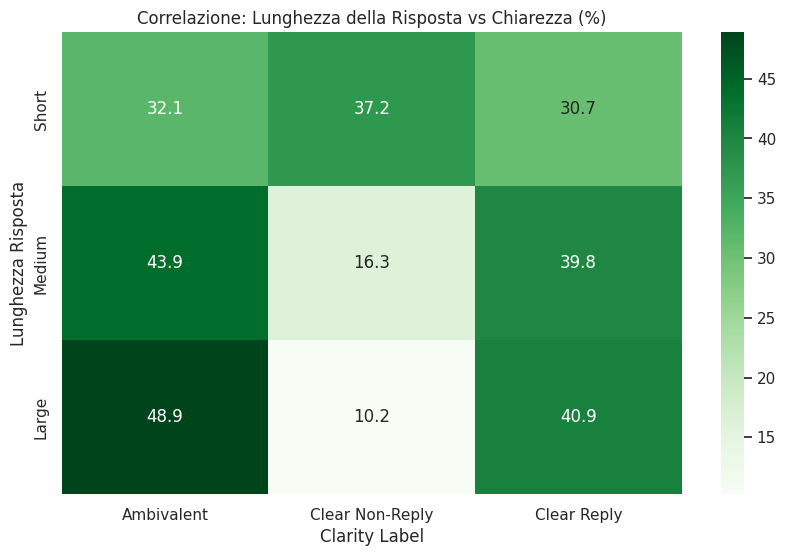

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Crosstab normalizzata per riga
length_clarity_ct = pd.crosstab(df_final_balanced['length_category'], df_final_balanced['clarity_label'], normalize='index') * 100

sns.heatmap(length_clarity_ct, annot=True, fmt='.1f', cmap='Greens')
plt.title('Correlazione: Lunghezza della Risposta vs Chiarezza (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Lunghezza Risposta')
plt.show()

In [47]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Inizializzazione modello con FP16 (obbligatorio per velocità su T4)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0,
                      torch_dtype=torch.float16)

candidate_labels = ["Assertive", "Guarded", "Dismissive"]

# 2. Trasformiamo la colonna in un oggetto Dataset di Hugging Face
# Tagliamo a 200 parole per assicurarci che la GPU non si "incanti"
print("Preparazione dati...")
temp_df = pd.DataFrame({
    "text": df_final_balanced['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:200]))
})
dataset = Dataset.from_pandas(temp_df)

# 3. Esecuzione con la struttura Dataset + Pipeline + tqdm
results = []
batch_size = 16

print(f"Inizio analisi batch di {len(dataset)} righe...")

for out in tqdm(classifier(KeyDataset(dataset, "text"),
                           candidate_labels=candidate_labels,
                           batch_size=batch_size,
                           truncation=True),
                total=len(dataset)):
    results.append(out['labels'][0])

# 4. Assegnazione finale
df_final_balanced['tone'] = results
print("Analisi completata!")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Preparazione dati...
Inizio analisi batch di 2816 righe...


  0%|          | 0/2816 [00:00<?, ?it/s]

Analisi completata!


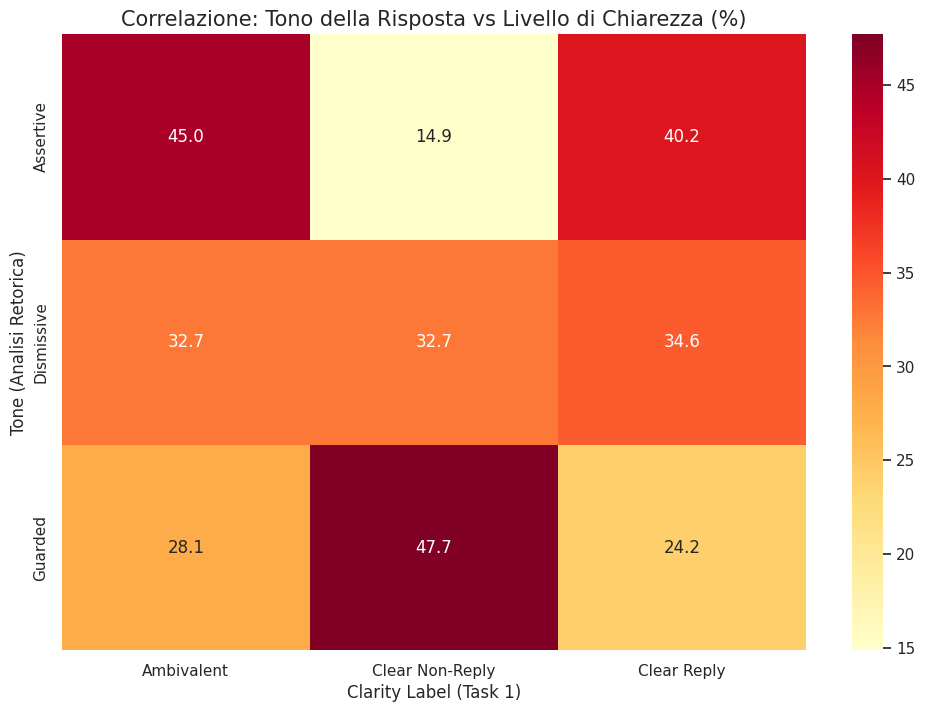

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo la tabella di contingenza (Crosstab)
tone_clarity_crosstab = pd.crosstab(df_final_balanced['tone'], df_final_balanced['clarity_label'], normalize='index') * 100

# Mostriamo la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tone_clarity_crosstab, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Correlazione: Tono della Risposta vs Livello di Chiarezza (%)', fontsize=15)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Tone (Analisi Retorica)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/balanced_heatmap_tone_clarity_4.png", bbox_inches='tight')
plt.show()

In [49]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Inizializzazione modello Emotion (Veloce e accurato)
emotion_classifier = pipeline("text-classification",
                              model="j-hartmann/emotion-english-distilroberta-base",
                              device=0 if torch.cuda.is_available() else -1,
                              top_k=1) # Vogliamo solo l'emozione principale

# 2. Prepariamo il Dataset (Taglio a 100 parole per coerenza e velocità)
print("Preparazione dati per Emotion Recognition...")
temp_df_emotion = pd.DataFrame({
    "text": df_final_balanced['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:100]))
})
dataset_emotion = Dataset.from_pandas(temp_df_emotion)

# 3. Esecuzione Batch
emotion_results = []
batch_size = 16

print(f"Inizio analisi emozioni su {len(dataset_emotion)} righe...")

for out in tqdm(emotion_classifier(KeyDataset(dataset_emotion, "text"),
                                   batch_size=batch_size,
                                   truncation=True),
                total=len(dataset_emotion)):
    # out è una lista di liste perché abbiamo usato top_k=1
    emotion_results.append(out[0]['label'])

df_final_balanced['emotion'] = emotion_results
print("Analisi emozioni completata!")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Preparazione dati per Emotion Recognition...
Inizio analisi emozioni su 2816 righe...


  0%|          | 0/2816 [00:00<?, ?it/s]

Analisi emozioni completata!


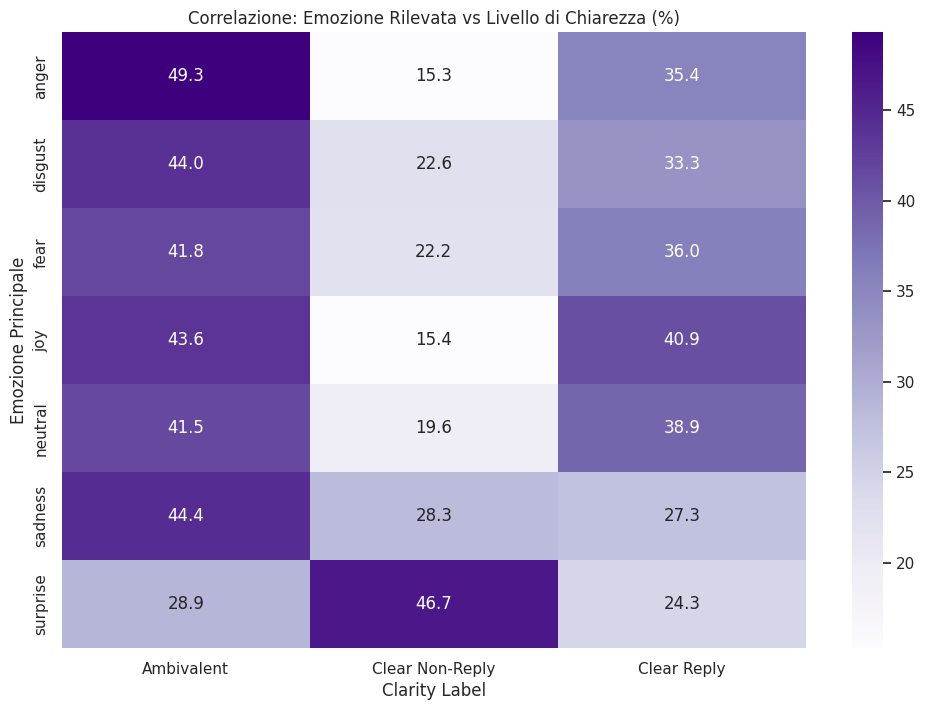

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# Crosstab tra emozioni e clarity_label
emotion_ct = pd.crosstab(df_final_balanced['emotion'], df_final_balanced['clarity_label'], normalize='index') * 100

sns.heatmap(emotion_ct, annot=True, fmt='.1f', cmap='Purples')
plt.title('Correlazione: Emozione Rilevata vs Livello di Chiarezza (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Emozione Principale')
plt.show()